In [ ]:
import kagglehub
import pandas as pd  # nao vai usar :(
import numpy as np
import pyspark.pandas as ps
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, coalesce, lower, regexp_replace, trim, when, length, upper , log1p
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
spark = SparkSession.builder.appName("roblox_games_data_analisys").getOrCreate()

In [ ]:
spark.conf.set("spark.sql.ansi.enabled", False)

# Leitura dataset

## Carregar datasets


In [ ]:
'''
roblox-games-data - 1/22/2022 to 5/2/2022 *outdated???

info: Date,Active Users,Favorites,Total Visits,Date Created,Last Updated,Server Size,Genre,Title

# Download latest version
roblox_games_data_path = kagglehub.dataset_download("databitio/roblox-games-data")

print("Path to dataset files:", roblox_games_data_path)
'''

'\nroblox-games-data - 1/22/2022 to 5/2/2022 *outdated???\n\ninfo: Date,Active Users,Favorites,Total Visits,Date Created,Last Updated,Server Size,Genre,Title\n\n# Download latest version\nroblox_games_data_path = kagglehub.dataset_download("databitio/roblox-games-data")\n\nprint("Path to dataset files:", roblox_games_data_path)\n'

In [ ]:
'''
roblox-games-dataset -  27/10/2024  *newest

info: Rank,Name,Active,Visits,Favorites,Likes,Deslikes,Rating
'''

# Download latest version
roblox_games_path = kagglehub.dataset_download("biggiefats/roblox-games-dataset")

print("Path to dataset files:", roblox_games_path)


Using Colab cache for faster access to the 'roblox-games-dataset' dataset.
Path to dataset files: /kaggle/input/roblox-games-dataset


In [ ]:
'''
roblox-dataset -  11/5/2024

info: Title,Creator,AgeRecomendation,ActivePlayers,Favorites,Visits,VoiceChat,
      Camera,Created,Updated,ServerSize,Genre,Likes,Dislikes,GameLink,Datafetch
'''

# Download latest version
roblox_dataset_path = kagglehub.dataset_download("jansenccruz/roblox-dataset")

print("Path to dataset files:", roblox_dataset_path)

Using Colab cache for faster access to the 'roblox-dataset' dataset.
Path to dataset files: /kaggle/input/roblox-dataset


In [ ]:
#Load dataframes

path=roblox_dataset_path+"/roblox_games_data.csv"
print(path)
df_old = spark.read.csv(path, header=True, inferSchema=True)

/kaggle/input/roblox-dataset/roblox_games_data.csv


In [ ]:
df_old=df_old.withColumnRenamed("Favorites","Favourites")

In [ ]:
df_old.show()

+--------------------+--------------------+-----------------+------+----------+-------+-------------+-------------+----------+----------+----------+---------------+-----+--------+--------------------+---------------+
|               Title|             Creator|AgeRecommendation|Active|Favourites| Visits|    VoiceChat|       Camera|   Created|   Updated|ServerSize|          Genre|Likes|Dislikes|            GameLink|    DateFetched|
+--------------------+--------------------+-----------------+------+----------+-------+-------------+-------------+----------+----------+----------+---------------+-----+--------+--------------------+---------------+
|Catalog Avatar Cr...|         @ItsMuneeeb|         All Ages| 19469|   3438844|  2.8B+|    Supported|    Supported|  7/4/2021| 11/5/2024|        24|       Shopping|  1M+|   124K+|https://www.roblo...|11/5/2024 20:24|
| [HALLOWEEN 🎃] T...|            CTStudio|         Ages 13+|  2709|   2911356|988.3M+|    Supported|Not Supported| 1/15/2021| 11/5/2

In [ ]:
path=roblox_games_path+"/roblox_games.csv"
print(path)
df_new = spark.read.csv(path, header=True, inferSchema=True)

/kaggle/input/roblox-games-dataset/roblox_games.csv


In [ ]:
df_new.show()

+----+--------------------+-------+--------------+----------+---------+---------+------+
|Rank|                Name| Active|        Visits|Favourites|    Likes| Dislikes|Rating|
+----+--------------------+-------+--------------+----------+---------+---------+------+
|  #1|         Blox Fruits|483,372|41,346,317,182|13,574,097|8,521,670|  676,846| 92.64|
|  #2|     Brookhaven 🏡RP|474,141|55,635,148,446|22,117,653|6,108,763|  955,845| 86.47|
|  #3| Dress To Impress 💜|297,764| 3,876,511,994| 3,182,036|2,042,092|  188,403| 91.55|
|  #4|    PETS GO! ✨ [NEW]|172,411|   145,691,211|   199,254|  275,267|   20,140| 93.18|
|  #5|    Murder Mystery 2|159,531|18,310,453,247|19,306,585|8,001,198|  786,705| 91.05|
|  #6|[UPDATE 1] Anime ...|142,586|   534,044,793|   578,491|1,592,383|   52,159| 96.83|
|  #7|The Strongest Bat...|142,531| 8,747,773,201| 4,177,434|2,931,689|  565,313| 83.83|
|  #8|Pet Simulator 99! 🎃|131,088| 1,527,851,114| 1,479,726|2,586,908|  106,245| 96.05|
|  #9|          Adopt Me

## Remove Duplicate Rows

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, desc, col

# For df_old: remove duplicates based on 'Title', keeping the most recent 'DateFetched'
window_old = Window.partitionBy("Title").orderBy(desc("DateFetched"))
df_old = df_old.withColumn("row_num", row_number().over(window_old)).filter(col("row_num") == 1).drop("row_num")

# print("df_old after removing duplicates by Title and keeping most recent DateFetched:")
# df_old.show(5, truncate=False)

In [ ]:
df_count = df_old.groupBy("Title").count().orderBy("count", ascending=False)
df_count.show()

+--------------------+-----+
|               Title|count|
+--------------------+-----+
| Anime Catching S...|    1|
|   Gun Armory Tycoon|    1|
| PETS GO! 🍀 [ +1...|    1|
| PETS GO! 🍀 [+1B...|    1|
| Piggy [DECAY CHA...|    1|
| Roblox Spirit Ha...|    1|
| SCP Containment ...|    1|
|    Sol's RNG [Eon1]|    1|
|   Sol's RNG [Era 9]|    1|
| Sonic Evocative:...|    1|
| Sonic.EXE: The D...|    1|
| Sonic.EXE: The d...|    1|
|        Strict Mom👿|    1|
| [ BUMBAA  + 16 ]...|    1|
| [ DIVA + 15] TOD 🎃|    1|
| [ 😇 ]GnomeCode'...|    1|
| [Fixed] Sonic Ev...|    1|
| [HALLOWEEN 🎃] T...|    1|
| [Modded TITANIC]...|    1|
| [RETURN] Z O th ...|    1|
+--------------------+-----+
only showing top 20 rows


In [ ]:
# For df_new: remove duplicates based on 'Name', keeping the one with the most 'Visits'
window_new = Window.partitionBy("Name").orderBy(desc("Visits"))
df_new = df_new.withColumn("row_num", row_number().over(window_new)).filter(col("row_num") == 1).drop("row_num")

# print("\ndf_new after removing duplicates by Name and keeping most Visits:")
# df_new.show(5, truncate=False)

In [ ]:
df_count = df_new.groupBy("Name").count().orderBy("count", ascending=False)
df_count.show()

+--------------------+-----+
|                Name|count|
+--------------------+-----+
|   Gun Armory Tycoon|    1|
| Michael's Zombie...|    1|
| Piggy [DECAY CHA...|    1|
|   Sol's RNG [Era 9]|    1|
| Sonic.EXE: The d...|    1|
| [ 🎃 HALLOWEEN ]...|    1|
| [HALLOWEEN 🎃] T...|    1|
|     🔥 Dragon Blox |    1|
|        🚁 My Prison|    1|
|(HALLOWEEN EVENT,...|    1|
|(HALLOWEEN) Inter...|    1|
|(UPDATE 7) King L...|    1|
|(🎃Halloween🎃) L...|    1|
|(📱 PHONES, MINIM...|    1|
|(🔪UPDATE🔪) Tha ...|    1|
|+1 Blocks Every S...|    1|
|+1 Fat Every Seco...|    1|
|         1% Win Obby|    1|
|2 Player Sushi Ty...|    1|
|3-2-1 Blast Off S...|    1|
+--------------------+-----+
only showing top 20 rows


## Normalização dos nomes

In [ ]:

EVENT_REGEX = (
    r"(?i)\b("
    r"new\s+update|big\s+update|mega\s+update|huge\s+update|balance\s+update|bug\s+fixes?|"
    r"update|upd|release|revamp|rework|patch|"
    r"halloween|christmas|xmas|winter|summer|spring|easter|valentine'?s?|thanksgiving|"
    r"black\s+friday|april\s+fools?|new\s+year|lunar\s+new\s+year|"
    r"free\s+ugc|ugc|limited\s+time|limited|new\s+codes?|codes?|code|rewards?|giveaway|"
    r"live\s+event|event|"
    r"new\s+map|new\s+world|new\s+area|new\s+island|new\s+pets?|new\s+eggs?|new\s+boss|"
    r"new\s+raid|new\s+weapons?|new\s+skins?|new\s+units?|new\s+fruit|new\s+quest|new\s+mode|"
    r"beta|alpha|demo|testing|early\s+access|open\s+beta|closed\s+beta"
    r")\b"
)

normalized_column_name="Normalized_name"

def criar_nome_normalizado(df, coluna_nome="Name"):
    return (
        df
        .withColumn(normalized_column_name, lower(col(coluna_nome)))

        # Remove emojis e símbolos estranhos
        .withColumn(
            normalized_column_name,
            regexp_replace(col(normalized_column_name), r"[^\w\s\-\:\|\!\(\)\[\]&']", " ")
        )

        # Remove blocos como [UPDATE], (HALLOWEEN), [NEW CODES]
        .withColumn(
            normalized_column_name,
            regexp_replace(
                col(normalized_column_name),
                r"(?i)[\[\(]\s*[^)\]]*(update|upd|event|codes?|ugc|halloween|christmas|xmas|easter|winter|summer|beta|alpha)[^)\]]*[\]\)]",
                " "
            )
        )

        # Remove palavras de evento/update
        .withColumn(
            normalized_column_name,
            regexp_replace(col(normalized_column_name), EVENT_REGEX, " ")
        )

        # Padroniza e limpa separadores
        .withColumn(normalized_column_name, regexp_replace(col(normalized_column_name), r"&", " and "))
        .withColumn(normalized_column_name, regexp_replace(col(normalized_column_name), r"[\[\]\(\)\|:!\-]", " "))
        .withColumn(normalized_column_name, regexp_replace(col(normalized_column_name), r"\s+", " "))
        .withColumn(normalized_column_name, trim(col(normalized_column_name)))

        # Se o resultado ficar vazio, volta para o nome original em lowercase
        .withColumn(
            normalized_column_name,
            when(length(col(normalized_column_name)) > 0, col(normalized_column_name))
            .otherwise(lower(col(coluna_nome)))
        )
    )

In [ ]:
df_old = criar_nome_normalizado(df_old,coluna_nome="Title")
#df_old.show()

In [ ]:
df_new = criar_nome_normalizado(df_new,coluna_nome="Name")
#df_new.show()

## Correção colunas numericas

In [ ]:
def correct_number_columns(col_name, num_type="bigint"):
    """
    Converts numeric string columns like:
    12K+ -> 12000
    1.5M -> 1500000
    2B   -> 2000000000
    950+ -> 950
    300  -> 300
    Handles commas in numbers.
    """

    c = upper(trim(col(col_name)))

    # Remove '+' wherever it appears, as it's not part of the number we want to cast
    c = regexp_replace(c, r"\+", "")

    # Remove commas from numbers (e.g., "483,372" -> "483372")
    c = regexp_replace(c, r",", "")

    # Extract only the numeric part and cast to DoubleType to handle decimals
    number = regexp_replace(c, r"[KMB]", "").cast(DoubleType())

    result = (
        when(c.rlike(r"K$"), number * 1000)
        .when(c.rlike(r"M$"), number * 1000000)
        .when(c.rlike(r"B$"), number * 1000000000)
        .otherwise(number)
        .cast(num_type) # Final cast to the desired integer type
    )

    return result

### Df_old

In [ ]:
df_old = df_old.withColumn("Likes", correct_number_columns("Likes", "bigint"))
df_old = df_old.withColumn("Dislikes", correct_number_columns("Dislikes", "bigint"))
df_old = df_old.withColumn("Active", correct_number_columns("Active", "int"))
df_old = df_old.withColumn("Favourites", correct_number_columns("Favourites", "bigint"))
df_old = df_old.withColumn("Visits", correct_number_columns("Visits", "bigint"))

### Df_new

In [ ]:
df_new=df_new.drop("Rank")
df_new=df_new.drop("Rating")

In [ ]:
df_new=df_new.withColumn("Active",correct_number_columns("Active","int"))
df_new=df_new.withColumn("Visits",correct_number_columns("Visits","bigint"))
df_new=df_new.withColumn("Favourites",correct_number_columns("Favourites","bigint"))
df_new=df_new.withColumn("Likes",correct_number_columns("Likes","bigint"))
df_new=df_new.withColumn("Dislikes",correct_number_columns("Dislikes","bigint"))

In [ ]:
cols_update = ["Visits", "Likes", "Dislikes", "Favourites", "Active"]

In [ ]:
df_new_update = df_new.select("Normalized_name",
        *[col(c).alias(f"{c}_new")
        for c in cols_update
        if c in df_new.columns]
)

## Juntar dataframes

In [ ]:
df_join = df_old.join(df_new_update, on="Normalized_name", how="left")

In [ ]:
for c in cols_update:
    new_col = f"{c}_new"

    if c in df_join.columns and new_col in df_join.columns:
        df_join = df_join.withColumn(
            c,
            coalesce(col(new_col), col(c))
        )

In [ ]:
df_final = df_join.drop(
    *[
        f"{c}_new"
        for c in cols_update
        if f"{c}_new" in df_join.columns
    ]
)

In [ ]:
df_final.show()

+--------------------+--------------------+--------------------+-----------------+------+----------+-----------+-------------+-------------+----------+----------+----------+-------------+-------+--------+--------------------+----------------+
|     Normalized_name|               Title|             Creator|AgeRecommendation|Active|Favourites|     Visits|    VoiceChat|       Camera|   Created|   Updated|ServerSize|        Genre|  Likes|Dislikes|            GameLink|     DateFetched|
+--------------------+--------------------+--------------------+-----------------+------+----------+-----------+-------------+-------------+----------+----------+----------+-------------+-------+--------+--------------------+----------------+
|anime catching si...| Anime Catching S...|           BestBunny|         All Ages|   206|    191886|   79300000|Not Supported|Not Supported| 1/13/2023| 8/15/2024|        12|   Simulation| 285000|   12000|https://www.roblo...| 11/9/2024 23:52|
|   gun armory tycoon|   Gun

In [ ]:
#df_final.printSchema()

# Analise inicial

## Ajustes (selecionar colunas numericas)

In [ ]:
df=df_final

In [ ]:
#df.printSchema()

In [ ]:
numeric_types = ["int", "bigint", "double", "float", "decimal", "long", "short"]

numeric_columns = [
    col_name
    for col_name, dtype in df.dtypes
    if dtype in numeric_types or dtype.startswith("decimal")
]
numeric_columns.append("Title")
numeric_columns.append("Genre")

In [ ]:
df_num=df.select(numeric_columns)

In [ ]:
#df_num.show()

In [ ]:
df_num=df_num.pandas_api()

In [ ]:
#df_num.head()

,Active,Favourites,Visits,ServerSize,Likes,Dislikes,Title,Genre
0,206,191886,79300000,12,285000,12000,Anime Catching Simulator,Simulation
1,1006,55544,32066588,8,46677,3736,Gun Armory Tycoon,Simulation
2,4281,1521,546300,10,1207,94,PETS GO! 🍀 [ +1B LUCK],N/A
3,1939,685,227800,10,588,42,PETS GO! 🍀 [+1B LUCK],N/A
4,27466,11669525,13110395425,6,3615821,406011,Piggy [DECAY CHAPTER],Survival


## Valores Nan/Null

In [ ]:
cols=df_num.columns

In [ ]:
for i in cols:
    print(i,df_num[i].isna().sum())
    print(i,df_num[i].isnull().sum())
    df_na=df_num[df_num[i]=="N/A"]
    print(f"{i} nan_string {df_na[i].count()}")


Active 0
Active 0
Active nan_string 0
Favourites 0
Favourites 0
Favourites nan_string 0
Visits 0
Visits 0
Visits nan_string 0
ServerSize 0
ServerSize 0
ServerSize nan_string 0
Likes 0
Likes 0
Likes nan_string 0
Dislikes 0
Dislikes 0
Dislikes nan_string 0
Title 0
Title 0
Title nan_string 0
Genre 0
Genre 0
Genre nan_string 487


## Analises

In [ ]:
num_cols=cols.drop("Title")
num_cols=num_cols.drop("Genre")

In [ ]:
df_num.head()

,Active,Favourites,Visits,ServerSize,Likes,Dislikes,Title,Genre
0,206,191886,79300000,12,285000,12000,Anime Catching Simulator,Simulation
1,1006,55544,32066588,8,46677,3736,Gun Armory Tycoon,Simulation
2,4281,1521,546300,10,1207,94,PETS GO! 🍀 [ +1B LUCK],N/A
3,1939,685,227800,10,588,42,PETS GO! 🍀 [+1B LUCK],N/A
4,27466,11669525,13110395425,6,3615821,406011,Piggy [DECAY CHAPTER],Survival


In [ ]:
df_num.describe()

,Active,Favourites,Visits,ServerSize,Likes,Dislikes
count,1534.000000,1.534000e+03,1.534000e+03,1534.000000,1.534000e+03,1.534000e+03
mean,4231.408735,9.806732e+05,4.501113e+08,25.663625,2.354806e+05,3.129972e+04
std,22273.500075,2.630438e+06,2.414365e+09,29.441246,7.088276e+05,9.274837e+04
min,0.000000,0.000000e+00,0.000000e+00,1.000000,0.000000e+00,0.000000e+00
25%,86.000000,7.506000e+03,1.400000e+06,10.000000,1.093000e+03,3.640000e+02
50%,804.000000,1.116010e+05,2.519544e+07,18.000000,2.300000e+04,3.757000e+03
75%,1924.000000,7.315230e+05,1.847692e+08,32.000000,1.400000e+05,2.153600e+04
max,483372.000000,2.873764e+07,5.563515e+10,700.000000,8.521670e+06,1.441230e+06


/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


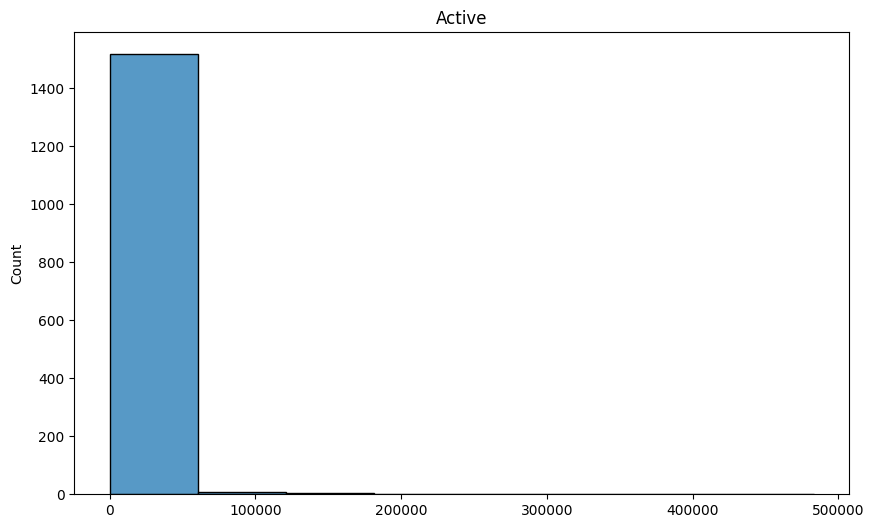

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


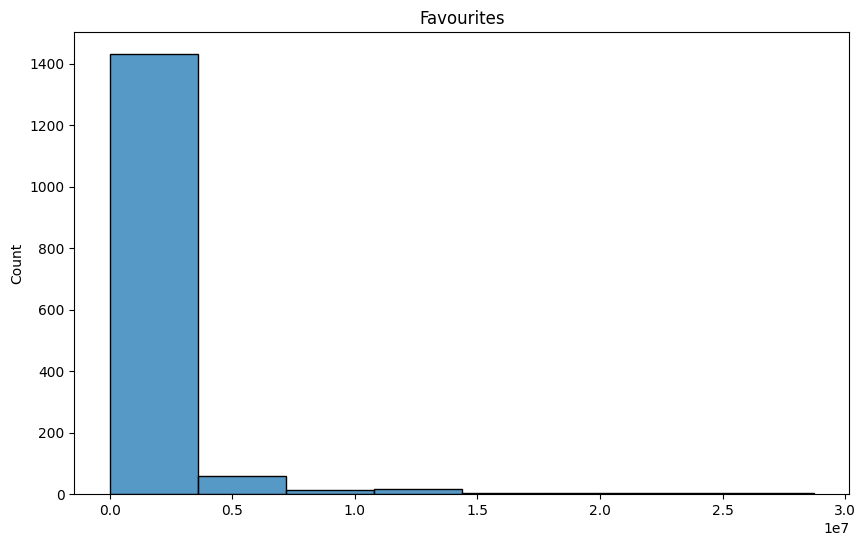

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


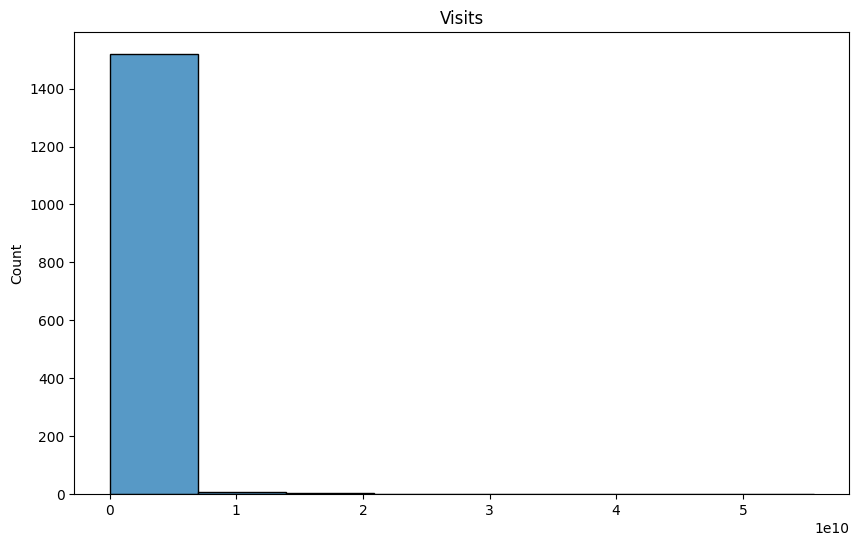

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


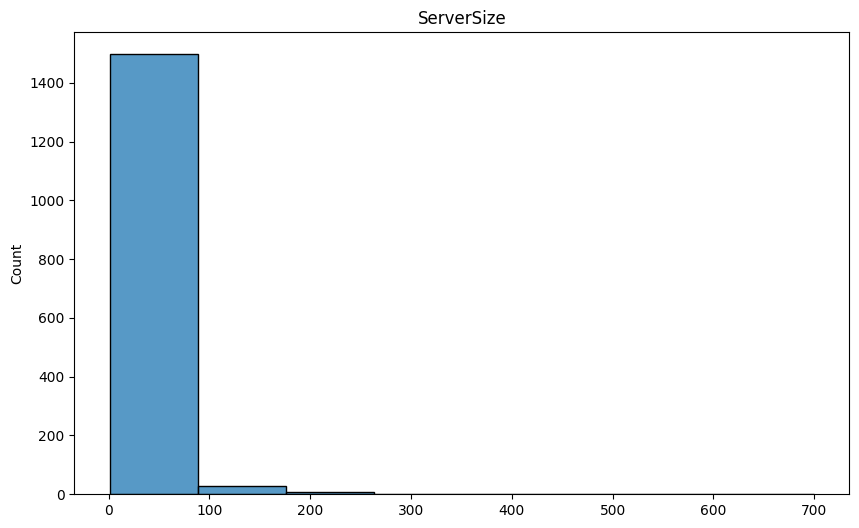

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


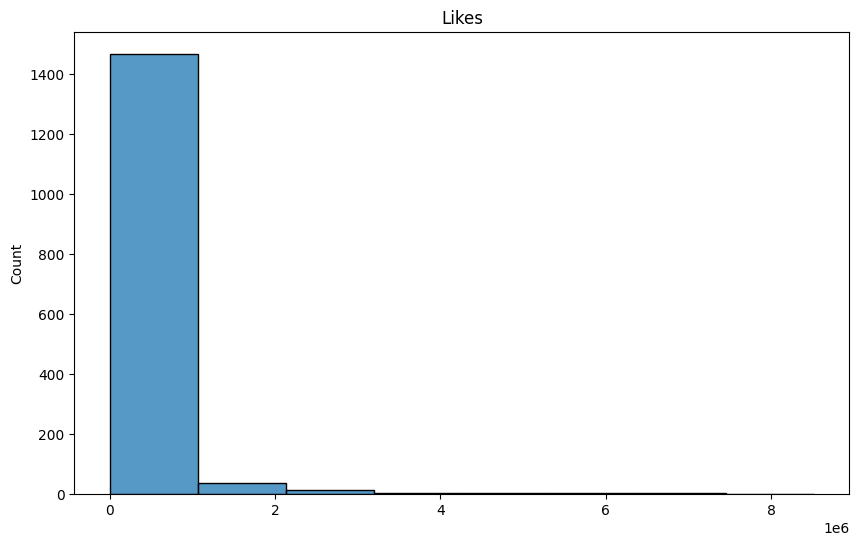

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


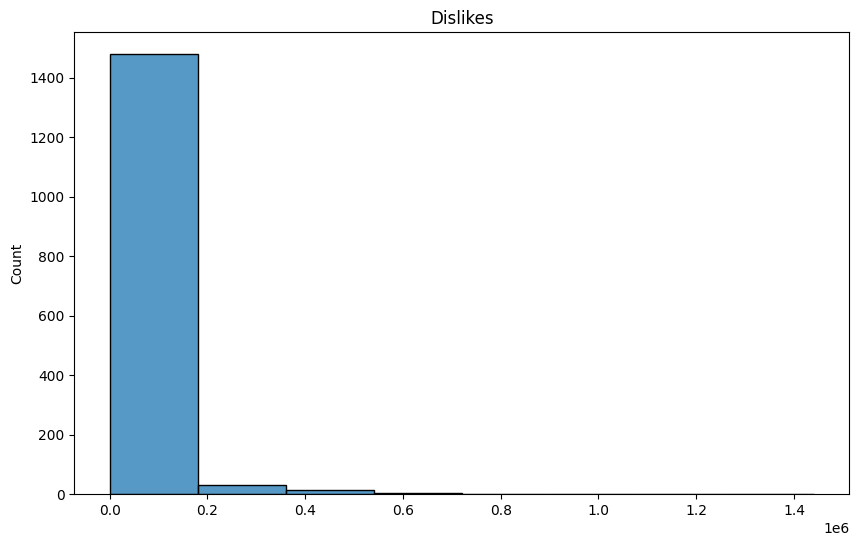

In [ ]:
# Distribuições
for i in num_cols:
  plt.figure(figsize=(10, 6))
  plt.title(i)
  sns.histplot(df_num[i].to_numpy(), bins=8)
  plt.show()

# PCA

In [ ]:
df_pca = df_final

cols_log = ["Active", "Visits", "Favourites", "Likes", "Dislikes"]
cols_sem_log = ["ServerSize"]

# Criar versões em log das colunas de contagem
for c in cols_log:
    df_pca = df_pca.withColumn(f"log_{c}", log1p(col(c).cast("double")))

# Converter ServerSize para double
df_pca = df_pca.withColumn("ServerSize", col("ServerSize").cast("double"))


In [ ]:
features_cols = [f"log_{c}" for c in cols_log] + cols_sem_log

assembler = VectorAssembler(
    inputCols=features_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

df_vector = assembler.transform(df_pca)

In [ ]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

In [ ]:
pca = PCA(
    k=3,
    inputCol="features_scaled",
    outputCol="pca_features"
)

pca_model = pca.fit(df_scaled)
df_pca_result = pca_model.transform(df_scaled)

In [ ]:
pca_model.explainedVariance

DenseVector([0.764, 0.162, 0.0429])